# Stage 4 - Explainability

A churn score is only useful to a retention team if they can see **why**. This
notebook explains the Stage 3 logistic-regression model two ways:

1. **Globally** - which features the model relies on overall
   (coefficients and permutation importance, plus a SHAP summary).
2. **Per customer** - for one customer, which factors push their risk up or down,
   in plain business language.

Everything here is **model evidence and association, not proof of cause**. Turning
factors into actions is Stage 6's job.

All logic lives in `src/explainability/`; this notebook calls it.

In [1]:
import sys
from pathlib import Path

here = Path.cwd()
project_root = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(project_root))

import json
import warnings

import numpy as np
import pandas as pd

from src.config import MODEL_PATH, DECISION_THRESHOLD_PATH, DATA_PROCESSED_DIR, FIGURES_DIR
from src.data.split import split_data
from src.models.train import load_model
from src.explainability import explainer as explain

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

model = load_model(MODEL_PATH)
decision_threshold = json.loads(DECISION_THRESHOLD_PATH.read_text())["threshold"]
split = split_data(pd.read_csv(DATA_PROCESSED_DIR / "telco_clean.csv"))
print("Loaded model and threshold:", round(decision_threshold, 3))

Loaded model and threshold: 0.243


## 1. Global importance - logistic-regression coefficients

In [2]:
importance = explain.global_importance(model)
importance.head(12).round(3)

,feature,coefficient,abs_coefficient
0,MonthlyCharges,-2.007,2.007
1,InternetService_Fiber optic,1.320,1.320
2,tenure,-1.308,1.308
3,InternetService_DSL,-1.138,1.138
4,Contract_Two year,-0.814,0.814
5,StreamingMovies_No internet service,-0.585,0.585
6,StreamingTV_No internet service,-0.585,0.585
7,TechSupport_No internet service,-0.585,0.585
8,DeviceProtection_No internet service,-0.585,0.585
9,OnlineSecurity_No internet service,-0.585,0.585


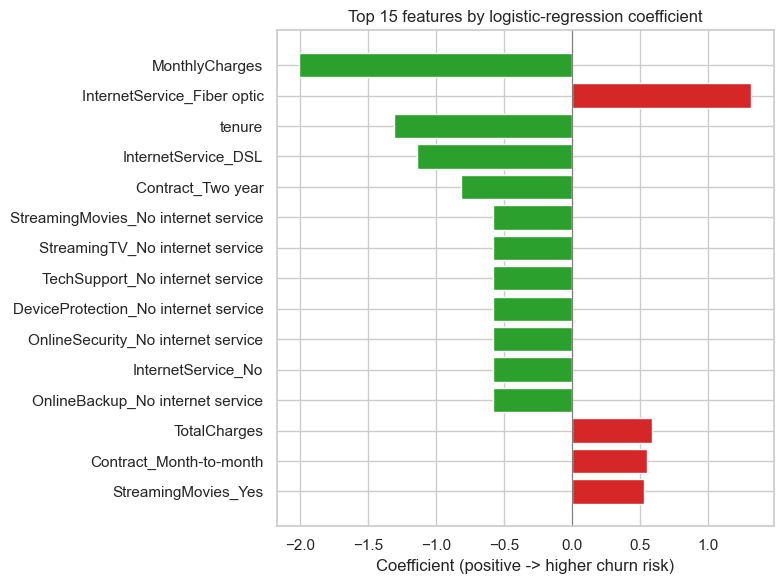

In [3]:
fig = explain.plot_global_importance(importance, top_n=15)
fig.savefig(FIGURES_DIR / "global_importance.png", dpi=120, bbox_inches="tight")

**Conclusion (read as associations, not causes):**
- Features associated with **higher** churn risk: **fibre-optic internet**,
  **short tenure**, and a **month-to-month contract**.
- Features associated with **staying**: **long tenure**, a **two-year contract**,
  and having **no internet service**.
- One sign looks surprising: `MonthlyCharges` has a **negative** coefficient even
  though higher bills usually feel risky. This is a multicollinearity effect -
  `MonthlyCharges` is strongly tied to `InternetService_Fiber optic`, so the model
  puts the churn signal on the fibre-optic flag and leaves `MonthlyCharges` with a
  negative partial coefficient. This is exactly why we do **not** read raw
  coefficients alone, and cross-check with permutation importance and SHAP below.

## 2. Global importance - permutation importance (business columns)

In [4]:
perm = explain.permutation_importance_scores(model, split.X_val, split.y_val, n_repeats=10)
perm.head(10).round(3)

,feature,importance,std
0,tenure,0.247,0.009
1,InternetService,0.233,0.017
2,MonthlyCharges,0.169,0.014
3,StreamingMovies,0.070,0.012
4,StreamingTV,0.047,0.010
5,Contract,0.047,0.012
6,TotalCharges,0.044,0.009
7,MultipleLines,0.040,0.008
8,DeviceProtection,0.021,0.007
9,PhoneService,0.019,0.004


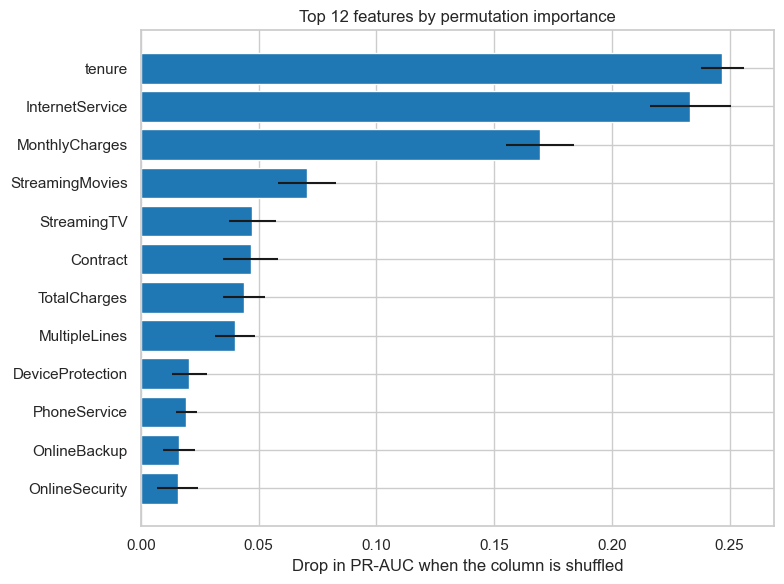

In [5]:
fig = explain.plot_permutation_importance(perm, top_n=12)
fig.savefig(FIGURES_DIR / "permutation_importance.png", dpi=120, bbox_inches="tight")

**Conclusion:** Permutation importance measures the drop in PR-AUC when a
column is shuffled, at the original-column level. The columns the model relies on
most are **tenure**, **InternetService**, **MonthlyCharges**, and **Contract**.
This agrees with the coefficients on the big drivers and is easier to read because
it works on whole business columns instead of one-hot pieces - and it does not
suffer from the coefficient sign issue.

## 3. Global importance - SHAP summary

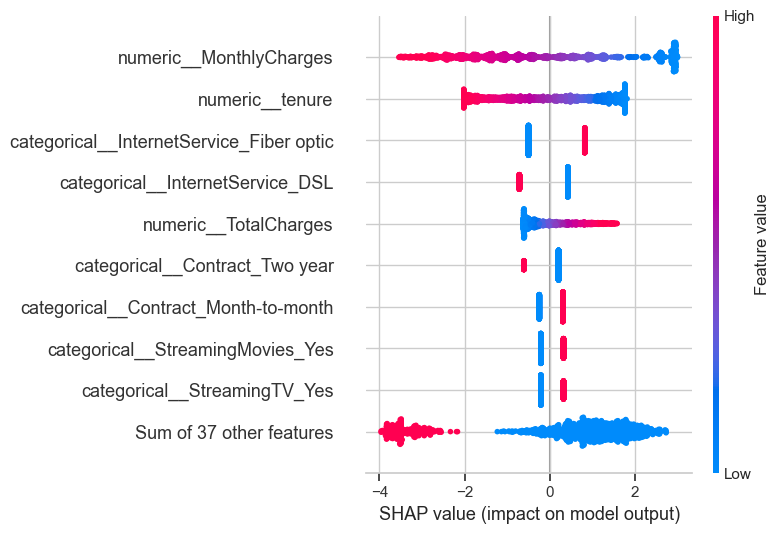

In [6]:
# Build a reusable explainer from the training data as the SHAP background.
explainer = explain.build_explainer(model, split.X_train, decision_threshold)

validation_explanation = explain.shap_values_for(explainer, split.X_val)
fig = explain.plot_shap_summary(validation_explanation)
fig.savefig(FIGURES_DIR / "shap_summary.png", dpi=120, bbox_inches="tight")

**Conclusion:** Each dot is one customer; colour is the feature value and the
horizontal position is the push toward churn (right) or staying (left). The
strongest spread comes from tenure, the internet-service flags, contract type, and
monthly charges - the same story as the other two views, now showing direction per
customer. Short tenure and fibre-optic internet sit on the churn side; long tenure
and two-year contracts sit on the staying side.

## 4. Per-customer explanations

In [7]:
# Pick the highest-risk and lowest-risk customers in the validation set as examples.
validation_proba = model.predict_proba(split.X_val)[:, 1]
high_risk_customer = split.X_val.iloc[[int(np.argmax(validation_proba))]]
low_risk_customer = split.X_val.iloc[[int(np.argmin(validation_proba))]]

high = explain.explain_customer(explainer, high_risk_customer)
print(f"Churn probability: {high['probability']:.1%}  ->  risk level: {high['risk_level']}")
print()
print("Factors INCREASING churn risk (strongest first):")
for factor in high["increases_risk"]:
    print(f"  + {factor['feature']:18s} = {str(factor['value']):20s} (contribution {factor['contribution']:+.2f})")
print()
print("Factors DECREASING churn risk (strongest first):")
for factor in high["decreases_risk"]:
    print(f"  - {factor['feature']:18s} = {str(factor['value']):20s} (contribution {factor['contribution']:+.2f})")

Churn probability: 85.1%  ->  risk level: High

Factors INCREASING churn risk (strongest first):
  + tenure             = 3                    (contribution +1.65)
  + InternetService    = Fiber optic          (contribution +1.39)
  + StreamingMovies    = Yes                  (contribution +0.59)
  + StreamingTV        = Yes                  (contribution +0.59)
  + Contract           = Month-to-month       (contribution +0.55)
  + MultipleLines      = Yes                  (contribution +0.33)
  + PaymentMethod      = Electronic check     (contribution +0.24)
  + OnlineSecurity     = No                   (contribution +0.21)
  + TechSupport        = No                   (contribution +0.19)
  + PaperlessBilling   = Yes                  (contribution +0.16)
  + SeniorCitizen      = 1                    (contribution +0.13)
  + OnlineBackup       = No                   (contribution +0.10)
  + Dependents         = No                   (contribution +0.08)
  + PhoneService       = Yes    

In [8]:
fig = explain.plot_customer_waterfall(explainer, high_risk_customer)
fig.savefig(FIGURES_DIR / "example_waterfall.png", dpi=120, bbox_inches="tight")

**Conclusion:** The explanation returns **all** material factors, sorted
strongest first and split into ones that raise risk and ones that lower it. For
this high-risk customer the risk is driven mainly by **short tenure**, **fibre-optic
internet**, and a **month-to-month contract**. The waterfall shows the same factors
adding up from the average prediction to this customer's score. The dashboard will
show the top five each way with an expandable "View all factors" section.

In [9]:
# A low-risk customer for contrast.
low = explain.explain_customer(explainer, low_risk_customer)
print(f"Churn probability: {low['probability']:.1%}  ->  risk level: {low['risk_level']}")
print()
print("Strongest factors DECREASING churn risk:")
for factor in low["decreases_risk"][:5]:
    print(f"  - {factor['feature']:18s} = {str(factor['value']):20s} (contribution {factor['contribution']:+.2f})")

Churn probability: 0.1%  ->  risk level: Low

Strongest factors DECREASING churn risk:
  - tenure             = 72                   (contribution -2.02)
  - Contract           = Two year             (contribution -0.82)
  - StreamingMovies    = No internet service  (contribution -0.53)
  - StreamingTV        = No internet service  (contribution -0.53)
  - InternetService    = No                   (contribution -0.52)


**Conclusion:** The low-risk customer's score is held down by **long tenure**
and a **longer contract**. Same explanation machinery, opposite story - which is
what we want for a tool a retention employee can trust.

## 5. Honest framing

- These factors describe **how the model uses the data**, not proven causes of
  churn. "Month-to-month contract increases the model's risk score" is not the
  same as "month-to-month contracts cause churn".
- Coefficients can have surprising signs when features overlap (the
  `MonthlyCharges` case above), so we always cross-check with permutation
  importance and SHAP.
- We deliberately do **not** make recommendations here. Stage 6 combines these
  risk factors with similar retained customers to suggest retention actions, with
  careful wording.

## Summary of Stage 4

1. Global coefficients, permutation importance, and a SHAP summary all point to the
   same main drivers: **tenure, internet service, contract type, and monthly
   charges**.
2. Flagged and explained the negative `MonthlyCharges` coefficient as a
   multicollinearity effect, and showed why permutation importance and SHAP give a
   cleaner business reading.
3. `explain_customer` returns a structured, plain-English breakdown (probability,
   risk level, all material factors split by direction, sorted strongest first) -
   ready for Stage 6 and the dashboard.
4. Kept strict honest framing: associations and model evidence, not proven causes.

**Next (Stage 5):** turn each customer into a feature vector with the same fitted
preprocessor, use cosine similarity to find similar customers who stayed, and build
the 2D customer map.